# **Not all samples are created equal : Deep Learning with Importance Sampling**

Angelos Katharopoulos, François Fleuret (2019)

Slide 2 :  
Aujourd'hui, les méthodes de Deep Learning sont de plus en plus évoluées, et l'accès à la data en grande quantité est démocratisé. Ainsi, il est désormais possible d'entraîner des réseaux de neurones de plus en plus complexes. Dans ce cadre-ci, il devient donc important de prêter attention au temps d'entraînement de tels modèles, qui peut vite devenir considérable.  

Or, au sein d'un ensemble d'entraînement, un grand nombre d'échantillons sont vite apprivoisés par le modèle, qui les classe correctement au bout de quelques epochs seulement. Ils ne lui apprennent ensuite plus rien, mais l'on continue de les faire passer à travers le réseau, lors de la phase forward (ce qui est logique pour continuer à les classer), mais aussi lors de la backpropagation (pour apprendre davantage d'informations au réseau, alors que ces exemples bien appréhendés ne lui apprennent plus grand-chose), à chaque itération, ce qui prend un temps colossal. Il convient donc de vouloir échantillonner nos données en choisissant simplement celles qui vont faire progresser le modèle le plus vite possible, afin de converger en moins d'itérations vers un modèle convenable.  

Slide 3 :   
C'est le principe de l'Importance Sampling, décrit dans l'article en question datant de 2019. L'objectif ici sera de trouver une manière intelligente de choisir les échantillons sur lesquels le modèle s'appuiera, en se basant sur le gradient de leur loss (l'écart entre leur valeur prédite et leur valeur réelle).

Slide 4 :  
L'objectif ici sera d'optimiser la vitesse de convergence de notre modèle (vers ses paramètres optimaux), en choisissant de manière intelligente quels samples seront pris en compte lors de la backpropagation du gradient. La convergence vers un modèle optimisé sera ainsi plus rapide en termes de nombre d'itérations, mais comme l'implémentation de cette méthode est temporellement coûteuse, on voudra donc choisir un faible nombre de samples pour qu'en termes de temps de calcul également ce soit avantageux.

Slide 5 :  
Concrètement, à partir d'un batch de taille B, on ne voudra garder que b << B images. A chaque itération, on va passer nos images à travers le réseau pour obtenir leur classification estimée,  et on va regarder si cela vaut le coup d'utiliser l'Importance Sampling, en fonction d'informations obtenues à l'itération précédente. Si jamais cette option est retenue, on va alors calculer la distribution de probabilité qui va nous amener à choisir seulement b samples pour la backpropagation.
Si l'on choisissait ces b samples de manière uniforme, il y aurait de fortes chances pour que l'on prenne en compte des images qui n'apprennent plus grand-chose au modèle car déjà bien classées dans les itérations précédentes. Ainsi, le modèle n'évoluera pas très vite vers un bon set de paramètres, on va avoir besoin de plus d'itérations pour y arriver.
On peut alors penser que pour converger le plus vite possible, on n'a qu'à prendre tous les échantillons en compte dans la phase de backpropagation, à la fois ceux qui sont déjà bien classés et ceux qui vont apprendre beaucoup au modèle. Or, passer autant d'images à nouveau dans le réseau prendrait énormément de temps, c'est pour quoi on ne va en garder que b. Mais d'abord, comment définit-t-on un échantillon difficile à classer ? Et bien ici, plutôt que de se baser sur la loss des échantillons (i.e. l'écart entre leur prédiction et leur valeur réelle), on va plutôt se baser sur le gradient de la loss, pour privilégier les échantillons dont la loss varie fortement, i.e. ceux dont la classification change beaucoup d'une itération à l'autre : le modèle n'arrive pas à les classer.

On note $N$ le nombre d'échantillons présent dans notre set total. La méthode classique consisterait à prendre un batch de $B < N$ échantillons en considération à chaque itération, que l'on passerait au sein du réseau de neurones, puis de se baser sur $b < B$ samples parmi eux choisis de manière uniforme, afin d'optimiser ses paramètres par backpropagation.

Slide 6 :  
On définit S la vitesse de convergence comme ceci, avec theta les paramètres du réseau de neurones à chaque itération, et theta* les paramètres optimaux. Après calcul, on trouve cette expression pour S, avec S_BGD la vitesse de convergence que l'on aurait si l'on prenait tous les B échantillons du batch en compte pour la backpropagation (trop coûteux comme je l'ai dit), et un terme de variance dépendant du gradient de la loss, et de pondérations wi, qui servent à compenser le choix de la distribution de probabilité (certains éléments seront vus plus souvents que d'autres, donc on va quand même atténuer leur impact sur le choix des paramètres sinon on ne se base que sur eux ce serait relou). On va donc vouloir minimiser ce terme de variance pour s'approcher au maximum de la vitesse de convergence optimale.

Slide 7 :  
Et en résolvant ce problème d'optimisation, on arrive à la distribution p* énoncée ici. Or, cette distribution est proportionnelle à la norme du gradient de la loss pour chaque échantillon. Ainsi, si l'on veut la calculer, on va devoir calculer le gradient de la loss de tout le monde, ce qui nécessite de repasser dans le réseau -> beaucoup trop chronophage finalement. On veut donc trouver une distribution qui s'en rapproche fortement mais qui est plus simple à calculer.

Slide 8 :  
La solution envisagée dans l'article serait de prendre une distribution de probabilité proportionnelle à une borne supérieure du gradient de la loss, mais qui soit plus simple à calculer. L'article nous donne un bon candidat, avec rho une constante, L le nombre de couches du réseau de neurones, sigma la fonction d'activation de la dernière couche. Ainsi, le calcul de la borne supérieure revient juste à regarder ce qui se passe en sortie du réseau, donc le calcul est bien plus rapide. On a donc une distribution de probabilité rapide à calculer pour choisir sur ce qui se baser : trop bien !

Slide 9 :  
Maintenant, on va tout de même vouloir savoir quand est-ce que c'est rentable d'utiliser une méthode d'Importance Sampling, qui prend quand même plus de temps que la méthode classique (il faut calculer la distribution de proba à chaque fois). On regarde donc le gain en réduction de variance que cela nous donne par rapport à une méthode où on choisit de manière uniforme les échantillons d'intérêt. On pose alors tau tel que le petit batch de taille b choisi avec l'IS réduise la variance du gradient de la loss autant qu'un batch choisi uniformément tau fois plus grand.

Slide 10 :  
Tout cela nous amène à l'algorithme final d'Importance Sampling, qui se présente comme suit : on choisit initialement B et b les tailles des batchs, tau_th le seuil de rentabilité de notre méthode, et theta les paramètres initiaux du réseau. A chaque itération du processus, on va comparer notre tau à tau_th, et si le seuil de rentabilité est dépassé, on va alors utiliser la méthode d'Importance Sampling à cette itération. On commence par choisir un batch de B images, calculer G^i la borne supérieure pour chaque image, et la distribution de proba p. On tire alors b images selon la loi p, et on effectue la backpropagation du gradient et la mise à jour des paramètres du réseau en se basant sur les b images choisies. Si le seuil de rentabilité n'est pas atteint, on tire seulement uniformément b images, c'est la méthode classique qui s'applique. A la fin de chaque itération, on met à jour tau pour pouvoir vérifier à celle d'après si l'on peut faire de l'Importance Sampling.

Slide 11 :  
L'article donne quelques exemples et met en évidence l'intérêt de l'Importance Sampling. On apprend surtout que c'est davantage efficace sur des problèmes complexes, en effet, si tous les échantillons sont plutôt rapidement bien classés, alors utiliser la méthode d'Importance Sampling prend plus de temps qu'autre chose, le temps perdu à calculer la distribution de probabilité n'est pas forcément gagné ensuite. Par contre pour des problèmes plus complexes ou des entraînements plus fins (ici sur plus de 20000 secondes par exemple), sur la durée la méthode d'IS devient rentable, le gain en vitesse de convergence est tellement important qu'il compense le fait que chaque itération soit plus lente. Le code exemple que j'ai rédigé reprend le dataset CIFAR100 illustré ici dans l'article, pour un modèle ResNet basique, et on voit bien que le gain, s'il existe, reste peu important pour un cas simple.

Slide 12 :  
Pour finir, lorsque l'on fait une descente de gradient uniforme, on passe beaucoup du temps sur des images qui sont vite maîtrisées par le modèle, donc n'apprennent plus grand-chose, et on a besoin de beaucoup d'itérations. En comparaison, la méthode d'Importance Sampling choisit intelligemment les échantillons d'intérêt, en réduisant la variance du gradient, et on converge plus rapidement vers un modèle uniforme. Le gain devient alors intéressant quand l'économie réalisée sur la backpropagation compense le coût du choix des échantillons. FIN

Maintenant, si l'on choisit ces samples de manière uniforme, il y a de fortes chances pour que l'on prenne en compte des images simples à classer qui vont peu affecter les paramètres du modèle, ce que l'on veut c'est optimiser les paramètres à l'aide des images qui vont le plus les influencer. La vitesse de convergence vers les paramètres optimaux augmenterait alors. Dans le cas idéal, on prendrait alors tous les $B$ samples pour effectuer la backpropagation, comme ça le réseau a connaissance de tous les échantillons, aussi bien ceux faciles à classer que ceux compliqués, et les paramètres du modèle seraient rapidement optimisés.

Or, cela prend beaucoup de temps, on va donc vouloir regarder moins d'échantillons. On va vouloir sélectionner $b << B$ échantillons, selon une distribution de probabilité bien choisie. On note $p_{i}$ la probabilité que l'échantillon i du batch de taille B soit choisi. Le but de l'article est de nous expliquer comment choisir les $p_{i}$ afin que les échantillons ayant le plus de chances d'être choisis soient ceux qui sont encore les moins bien apprivoisés par le modèle. Ce sont ceux dont la loss est la plus variable (la classification change encore d'une itération à l'autre), i.e. ceux dont le gradient de leur loss est le plus élevé.  

Notant $θ_{t}$ le set de paramètres du réseau de neurones considéré à l'étape t de l'entraînement, on définit la vitesse de convergence de l'entraînement de notre modèle vers le set de paramètres optimal $\theta^*$ comme $S = - \mathbb{E}[ ||\theta_{t+1} - \theta^*||^2 - [[\theta_{t}-\theta^*||^2]$. On définit $I_t$ comme une variable aléatoire représentant l'indice de l'échantillon sélectionné à l'instant t. On pose également $w_i = \frac{1}{Bp_i}$ et $\eta$ le learning rate du modèle, de sorte que pour chaque itération $t$, $\theta_{t+1} = \theta_t - \eta w_{I_t}^{(t)}\nabla_{\theta_t}\mathbf{L}(\Phi(x_{I_t},\theta_t),y_{I_t}) = \theta_t - \eta G_{I_t}$, avec $(x_t,y_t)$ les images et leur classifications à l'itération t. Pour une batch size de b, on mettra à jour $\theta$ en moyennant selon cette formule sur tous les échantillons choisis.

On remarque donc que moins un point va avoir de chances d'être choisi ($p_i → 0$), plus son poids $w_i$ associé sera élevé, ainsi le fait que l'on ne voit pas souvent ce point est compensé par le fait que la fois où on le verra, il influencera fortement la modification des paramètres $\theta$.  

On note $S_{BGD}$ la vitesse de convergence atteinte dans le cas où l'on prend l'intégralité du batch de taille B pour effectuer l'entraînement. Cette vitesse de convergence est la vitesse maximale que l'on pourrait atteindre dans notre cas, le but sera donc de faire en sorte de s'en rapprocher le plus possible. On rappelle que le but est de converger bien plus rapidement vers les paramètres optimaux qu'avec la méthode aléatoire, mais en prenant moins d'échantillons que si l'on prenait tout le batch (comme ça le temps d'exécution d'une itération reste acceptable).  
Après développement de l'expression de S en fonction des expressions des $\theta_t$, on trouve que $S = S_{BGD} - \eta^2 Tr(\mathbb{V}(G_{I_t}))$.

Ainsi, on va vouloir minimiser la variance du gradient de la loss pour se rapprocher de la vitesse optimale, tout en gagnant du temps en prenant bien moins de samples. La problématique ici est que le calcul de la distribution de probabilité minimisant $\mathbb{V}(G_{I_t})$ peut prendre du temps. En effet, le problème d'optimisation que l'on cherche à résoudre ici à pour solution $$p_i^* = \frac{\|\nabla_{\theta} L_i(\theta)\|}{\sum_{j=1}^N \|\nabla_{\theta} L_j(\theta)\|}$$ qui est donc proportionnelle à la norme du gradient de la loss.  
Si l'on doit calculer la norme du gradient de la loss de chaque point à chaque fois, le coût temporel est colossal donc on ne s'y retrouverait pas.  

L'astuce de la méthode présentée ici est de définir les $p_i$ à partir d'une borne supérieure du gradient qui serait plus facile à calculer. En définissant $\Sigma_k$ la fonction d'activation de la couche k notre réseau de neurones, L le nombre de couches du réseau, et $z_{i}^{(k)}$ la valeur en sortie de la couche k avant activation, après calcul on trouve : $$\hat{G}_i = L \rho \| \Sigma_{L}'(z_{i}^{(L)}) \nabla_{x_{i}^{(L)}} \mathbf{L} \|$$, où $\rho$ est une constante d'un échantillon à l'autre.

Mathématiquement, cette borne supérieure revient à regarder l'erreur brute en sortie du réseau. Si le réseau se trompe fort, la norme est grande, donc l'échantillon est important. C'est un calcul instantané qui ne demande pas de remonter tout le réseau, et le calcul de la distribution de probabilité n'est donc plus tant coûteux : $$p_i ∝ \hat{G}_i$$

On va maintenant vouloir évaluer à quel point notre variance a été réduite, par rapport au cas où l'on utiliserait une distribution uniforme pour choisir nos échantillons. Notant $u = \frac{1}{B}$ la distribution uniforme, on a alors :
$$\frac{Tr(\mathbb{V}_u(G_i)) - Tr(\mathbb{V}_p(w_iG_i))}{Tr(\mathbb{V}_u(G_i))} = ... = \frac{1}{\sum{p_i^2}}\|p - u\|^2 = 1 - \frac{1}{\tau}$$
où l'on pose $\tau$ comme étant un paramètre définissant l'incrément de la batch size équivalent à l'usage de cette méthode : $\tau = 2 ⇔$ le petit batch choisi par importance sampling réduit autant la variance du gradient de la loss qu'un batch uniforme deux fois plus grand.  

C'est sur cette grandeur $\tau$ que l'on va se baser pour définir si cela est rentable ou non d'utiliser l'importance sampling.

L'algorithme suivant synthétise donc le principe de l'importance sampling, afin d'entraîner les paramètres du modèle sur un minimum d'images, les plus dures à classer, tout en ne perdant pas trop de temps à calculer tous les gradients de loss pour savoir les identifier.

```
Initialisation de :
  - B la taille du grand batch à partir duquel on classe nos images, et dans lequel on va venir piocher pour optimiser les paramètres du modèle
  - b la taille du mini batch qui va servir à mettre à jour les paramètres du réseau de neurones
  - tau_th le seuil de rentabilité au-delà duquel l'importance sampling sera privilégié (quand tau > tau_th)
  - theta le set de paramètres initiaux du réseau de neurones

Si tau >= tau_th :
  - on choisit B images uniformément
  - on calcule les G^i, borne supérieure du gradient, pour les B images
  - on choisit b images avec la distribution p calculée proportionnellement à G^i
  - On met à jour les paramètres theta, en se basant uniquement sur les b images choisies, pondérées par les poids w_i
  
Si tau < tau_th :
  - SGD classique, on tire directement b samples au hasard, avec pondération w_i = 1
  - on calcule tout de même les importances proortionnelles à G^i pour mettre à jour tau

Mise à jour de tau avec lissage

Répétition jusqu'à convergence
```

Il est conseillé d'utiliser Google Colab pour run ce notebook, et préférable d'utiliser la configuration GPU, même si l'entraînement des modèles sans dure environ 15 minutes.

Passons maintenant à la démonstration expérimentale de la partie théorique. Nous allons entraîner un réseau de neurones sur un jeu de données afin de faire de la classification d'images, à la fois en choisissant de manière uniforme les échantillons qui vont servir à la backpropagation du réseau, et en utilisant la méthode d'Importance Sampling.  

On regardera alors l'évolution de la loss au fûr et à mesure de l'entraînement, à la fois vis-à-vis du temps d'exécution et du nombre d'itérations. On s'attend à ce que la méthode d'Importance Sampling prenne davantage de temps pour run les itérations, car il y a quand même l'étape de calcul des $\hat{G}_{i}$ qui entre en jeu. En revanche, la loss devrait diminuer plus vite en termes de nombre d'itérations que pour la méthode uniforme.  

On choisit ici d'entraîner un modèle ResNet18 (assez simple), sur le jeu de données CIFAR-100, pris en exemple dans l'article. Notre réseau de neurones est simple, tout comme le jeu de données, ce qui fait que l'on ne s'attend pas à avoir des résultats aussi flagrants que voulus, mais on se limitera à cette configuration pour garder un temps d'entraînement faible.  

L'entraînement prend une quinzaine de minutes pour les deux modèles cumulés, mais beaucoup moins si l'on se place en GPU.

In [1]:
# Importation des packages nécessaires

import time
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np

In [2]:
# Définition de la classe ImportanceSamplingTrainer, qui implémente la méthode d'Importance Sampling

class ImportanceSamplingTrainer:
    def __init__(self, model, optimizer, B=256, b=32, tau_th=1.2, a_tau=0.9):
        """
        B : Taille du réservoir (le grand échantillon U)
        b : Taille du batch final (le petit échantillon G)
        tau_th : Seuil de rentabilité pour activer l'Importance Sampling
        a_tau : Coefficient de lissage pour la moyenne mobile de tau
        """
        self.model = model
        self.optimizer = optimizer
        self.B = B
        self.b = b
        self.tau_th = tau_th
        self.a_tau = a_tau
        self.tau = 0.0
        self.criterion_none = nn.CrossEntropyLoss(reduction='none')
        self.device = next(model.parameters()).device

    def compute_tau(self, gi):
        """
        Estimation du gain de réduction de variance tau, en fonction des valeurs de G_hat
        """
        numerator = np.sum(gi**2)
        mean_g = np.mean(gi)
        denominator = np.sum((gi - mean_g)**2)

        if denominator == 0:
          return 1.0
        tau_t = 1.0 / (1.0 - (denominator / numerator))
        return tau_t

    def train_one_step(self, dataloader_iter):
        """
        Implémentation d'une étape d'entraînement de l'importance sampling.
        """

        # On lit le dataloader, s'il est vide, on renvoie None pour signaler la fin de l'epoch
        try:
              batch_data = next(dataloader_iter)
        except StopIteration:
            return None, self.tau

        # On envoie les images sur le device
        images_U, labels_U = batch_data
        images_U, labels_U = images_U.to(self.device), labels_U.to(self.device)

        current_B = len(images_U)

        # Si tau est supérieur au seuil tau_th, on va utiliser l'importance sampling
        use_is = self.tau > self.tau_th

        if use_is:

            # Forward pass rapide des B images du batch
            self.model.eval()
            with torch.no_grad():
                outputs_U = self.model(images_U)
                probs_U = torch.softmax(outputs_U, dim=1)
                one_hot_labels = torch.nn.functional.one_hot(labels_U, num_classes=outputs_U.size(1))
                # On va approximer la borne supérieure de la norme du gradient comme étant la norme de la distance entre les labels
                # des échantillons et probs_U (ce qu'il y a en sortie de la fonction d'activation de la dernière couche)
                gi = torch.norm(probs_U - one_hot_labels, p=2, dim=1).cpu().numpy()

            # On calcule la distribution de probabilité p_sampling comme étant proportionnelle aux gi
            p_sampling = gi / gi.sum()
            actual_b = min(self.b, current_B)

            # Choix de b samples tirés avec la distribution de probabilité p_sampling
            indices = np.random.choice(current_B, size=actual_b, p=p_sampling, replace=False)

            images_G = images_U[indices]
            labels_G = labels_U[indices]

            # Calcul des poids wi : pour atténuer l'importance des éléments que l'on voit le plus souvent (inversement proportionnel
            # à la distribution de probabilité)
            wi = 1.0 / (self.B * p_sampling[indices])
            wi = torch.from_numpy(wi).to(self.device).float()
            # Normalisation des poids pour la stabilité numérique
            wi = wi / wi.mean()
            wi = torch.clamp(wi, max=10.0)

        # Si tau < tau_th, les images servant à la backpropagation sont sélectionnées de manière uniforme
        else:

            # On prend juste b échantillons tirés suivant une loi uniforme
            images_G = images_U[:self.b]
            labels_G = labels_U[:self.b]
            # Les poids wi valent tous 1
            wi = torch.ones(self.b).to(self.device)

            # On calcule quand même gi pour mettre à jour tau
            self.model.eval()
            with torch.no_grad():
                outputs_G = self.model(images_G)
                probs_G = torch.softmax(outputs_G, dim=1)
                one_hot_labels = torch.nn.functional.one_hot(labels_G, num_classes=outputs_G.size(1))
                gi = torch.norm(probs_G - one_hot_labels, p=2, dim=1).cpu().numpy()


        self.model.train()
        self.optimizer.zero_grad()
        outputs = self.model(images_G)
        # Backpropagation du réseau sur les b échantillons choisis (mise à jour des poids du réseau)
        # On applique les poids wi sur la loss de chaque échantillon
        loss = (self.criterion_none(outputs, labels_G) * wi).mean()
        loss.backward()
        self.optimizer.step()

        # Mise à jour de tau par moyenne mobile
        tau_t = self.compute_tau(gi)
        self.tau = self.a_tau * self.tau + (1 - self.a_tau) * tau_t

        # On renvoie la loss et la valeur de tau après chaque itération
        return loss.item(), self.tau

In [3]:
# Fonction d'entraînement d'un réseau de neurones avec le choix des échantillons selon une loi uniforme
# (servira pour comparer les temps d'exécution des méthodes choisies)

def train_uniform_method(model_state, steps):
    print("--- Démarrage Baseline Uniforme ---")
    # Récupération du modèle et de l'optimiseur
    model = get_model()
    model.load_state_dict(model_state)
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    iter_loader = iter(loader_Uniform)

    # Initialisation des listes contenant les temps et les losses à chaque itération
    times = []
    losses = []
    start_time = time.time()

    model.train()
    # Itérations sur steps epochs
    for step in range(steps):

        # On récupère le batch de données
        try:
            inputs, labels = next(iter_loader)
        except StopIteration:
            iter_loader = iter(loader_Uniform)
            inputs, labels = next(iter_loader)

        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # Pass forward dans le réseau
        optimizer.zero_grad()
        outputs = model(inputs)
        # Calcul de la loss et backpropagation
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Calcul du temps d'exécution à chaque checkpoint
        if step % 10 == 0:
            elapsed = time.time() - start_time
            times.append(elapsed)
            losses.append(loss.item())

        if step % PRINT_EVERY == 0:
            print(f"[Uniforme] Step {step}/{steps} | Loss: {loss.item():.4f} | Temps: {elapsed:.1f}s")

    return times, losses

In [4]:
# Fonction d'entraînement d'un réseau de neurones avec le choix des échantillons selon l'importance sampling

def train_is_method(model_state, steps):
    print("--- Démarrage Importance Sampling ---")
    # Récupération du modèle et de l'optimiseur
    model = get_model()
    model.load_state_dict(model_state)
    # Le choix du learning rate peut varier, ici il est pris relativement élevé (0.01) pour que les sauts
    # effectués soient plus grands à chaque itération, et donc pour mettre en évidence que le fait
    # d'utiliser l'Importance Sampling nous fait quand même sauter dans la bonne direction
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    # Instanciation de l'Importance Sampling Trainer
    trainer = ImportanceSamplingTrainer(model, optimizer, B=B, b=b, tau_th=1.2)
    iter_loader = iter(loader_IS)

    # Initialisation des listes contenant les temps et les losses à chaque itération
    times = []
    losses = []
    start_time = time.time()

    # Itérations sur steps epochs
    for step in range(steps):

        # Appel à la fonction train_one_step pour utiliser l'Importance Sampling
        loss, current_tau = trainer.train_one_step(iter_loader)

        # Si loss est None, on arrive à la fin du dataloader
        if loss is None:
            # On reset l'itérateur
            iter_loader = iter(loader_IS)
            # On relance un pas immédiatement pour ne pas perdre l'itération
            loss, current_tau = trainer.train_one_step(iter_loader)

        # Enregistrement des temps
        if step % 10 == 0:
            elapsed = time.time() - start_time
            times.append(elapsed)
            losses.append(loss)

        if step % PRINT_EVERY == 0:
            mode = "IS" if trainer.tau > trainer.tau_th else "Warmup"
            print(f"[Méthode IS] Step {step}/{steps} | Loss: {loss:.4f} | Tau: {trainer.tau:.2f} | Mode: {mode} | Temps: {elapsed:.1f}s")

    return times, losses

In [5]:
# Configuration de l'entraînement (nombre d'échantillons sélectionnés, d'itérations, ...)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
B = 128
b = 64
STEPS = 3000
PRINT_EVERY = 50

# Récupération des données CIFAR-100
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# Dataloader pour Importance Sampling (gros batchs B)
loader_IS = torch.utils.data.DataLoader(trainset, batch_size=B, shuffle=True, num_workers=4)

# Dataloader pour échantillonnage uniforme (petits batchs b pour que la comparaison soit pertinente)
loader_Uniform = torch.utils.data.DataLoader(trainset, batch_size=b, shuffle=True, num_workers=2)

# Définition du modèle ResNet18
def get_model():
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 100)
    return model.to(DEVICE)

# On crée un état initial commun pour l'équité
initial_model = get_model()
initial_state = copy.deepcopy(initial_model.state_dict())

# Entraînement en suivant la méthode uniforme
t_unif, l_unif = train_uniform_method(initial_state, STEPS)

# Entraînement en suivant la méthode d'importance sampling
t_is, l_is = train_is_method(initial_state, STEPS)

100%|██████████| 169M/169M [00:19<00:00, 8.62MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warn

--- Démarrage Baseline Uniforme ---
[Uniforme] Step 0/3000 | Loss: 4.7151 | Temps: 1.3s
[Uniforme] Step 50/3000 | Loss: 4.7960 | Temps: 2.7s
[Uniforme] Step 100/3000 | Loss: 4.1337 | Temps: 4.4s
[Uniforme] Step 150/3000 | Loss: 4.2175 | Temps: 5.8s
[Uniforme] Step 200/3000 | Loss: 4.1555 | Temps: 7.0s
[Uniforme] Step 250/3000 | Loss: 3.9361 | Temps: 8.3s
[Uniforme] Step 300/3000 | Loss: 4.1268 | Temps: 9.6s
[Uniforme] Step 350/3000 | Loss: 3.5414 | Temps: 10.8s
[Uniforme] Step 400/3000 | Loss: 3.6536 | Temps: 12.1s
[Uniforme] Step 450/3000 | Loss: 3.5326 | Temps: 13.3s
[Uniforme] Step 500/3000 | Loss: 3.5809 | Temps: 14.5s
[Uniforme] Step 550/3000 | Loss: 3.6937 | Temps: 16.1s
[Uniforme] Step 600/3000 | Loss: 3.4801 | Temps: 18.3s
[Uniforme] Step 650/3000 | Loss: 3.6898 | Temps: 19.6s
[Uniforme] Step 700/3000 | Loss: 3.3885 | Temps: 20.9s
[Uniforme] Step 750/3000 | Loss: 3.4718 | Temps: 22.1s
[Uniforme] Step 800/3000 | Loss: 3.2954 | Temps: 23.5s
[Uniforme] Step 850/3000 | Loss: 3.3091

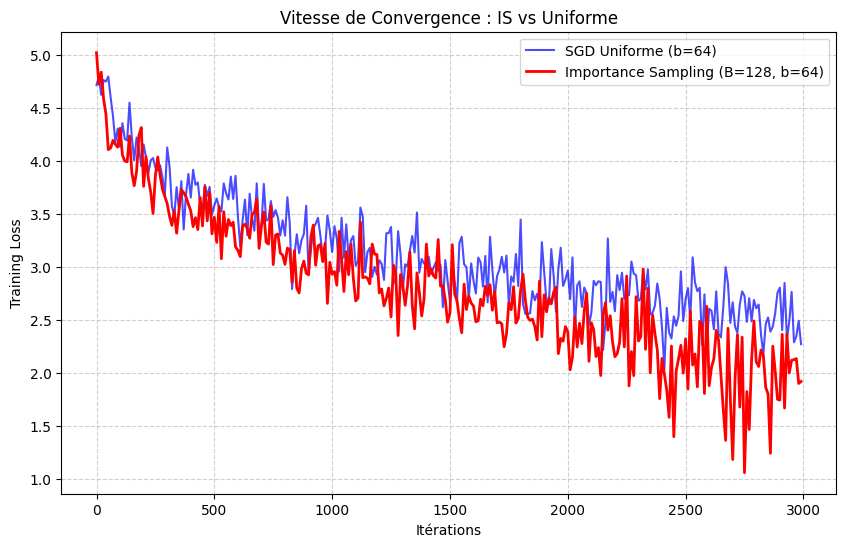

In [6]:
iterations = np.arange(len(l_unif)) * 10

plt.figure(figsize=(10, 6))
plt.plot(iterations, l_unif, label=f'SGD Uniforme (b={b})', alpha=0.7, color='blue')
plt.plot(iterations, l_is, label=f'Importance Sampling (B={B}, b={b})', linewidth=2, color='red')

plt.xlabel('Itérations')
plt.ylabel('Training Loss')
plt.title('Vitesse de Convergence : IS vs Uniforme')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

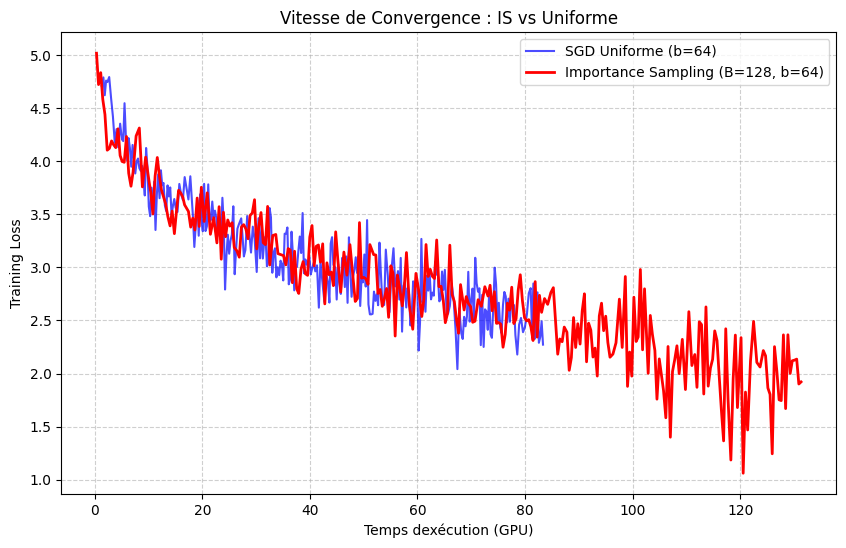

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(t_unif, l_unif, label=f'SGD Uniforme (b={b})', alpha=0.7, color='blue')
plt.plot(t_is, l_is, label=f'Importance Sampling (B={B}, b={b})', linewidth=2, color='red')

plt.xlabel('Temps d''exécution (GPU)')
plt.ylabel('Training Loss')
plt.title('Vitesse de Convergence : IS vs Uniforme')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

On observe ici qu'à nombre d'itérations égales (premier graph), la méthode d'Importance Sampling donne des valeurs de Training Loss assez significativement inférieures à celles obtenues par la méthode "classique". Toutefois, lorsque l'on regarde en termes de temps d'exécution (second graph), puisque chaque itération est plus lente lors de la méthode d'Importance Sampling (il faut calculer les distributions de probabilités avant de choisir les échantillons d'intérêt), la loss décroît finalement aussi rapidement dans les deux méthodes. Il faut aussi garder en tête que c'est la loss calculée sur l'ensemble d'entraînement ici, donc pour un ensemble de test, les résultats ne seront pas forcément les mêmes, même si on s'attend (cf article) à ce que les tendances observées finissent par être semblables asymptotiquement.

Ici, puisque l'on se place en GPU, on peut se permettre de prendre b = 64, ce qui est important, pour B = 128. En revanche, si l'entraînement devient plus complexe (réseau de neurones avec plus de couches par exemple), ou si l'on ne dispose pas du GPU, il conviendra de prendre un b plus faible. Il faudra tout de même faire attention à ne pas le prendre trop petit, parce que si l'on ne prend que trop peu d'échantillons pour la backpropagation, il est possible quand même que l'on en prenne qui ne sont pas pertinents, et que l'on se dirige alors dans le mauvaise direction. Il faut donc trouver un compromis entre prendre assez d'éléments pour optimiser la vitesse de convergence, et ne pas en prendre trop pour ne pas que cela prenne trop de temps.


Ici, puisque la méthode classique arrive à produire une loss satisfaisante en assez peu d'itérations, l'intérêt de la méthode d'importance sampling est reste moindre. Mais l'on voit bien que pour des modèles plus complexes nécessitant davantage d'itérations, il sera préférable d'utiliser cette méthode, car on pourra alors s'arrêter à bien moins d'itérations et quand même avoir une loss convenable, le gain en nombre d'itérations surpassant alors la perte de temps occasionné par l'usage de l'importance sampling à chaque step.